# Analytic report over de populariteit van tedtalks
### connectie met db maken door middel van bestaande functie

In [137]:
from db_conn import create_connection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# is er een verband tussen video tags en populareit van een video?
### data ophalen uit database

In [138]:
conn = create_connection()
cur = conn.cursor()
query = """
SELECT t.id AS tag_id,
       AVG(s.views) AS average_views,
        AVG(s.likes) AS average_likes

FROM tags t
JOIN video_tags vt ON t.id = vt.tag_id
JOIN video_data vd ON vt.video_id = vd.video_id
JOIN statistic s ON s.video_id = vd.video_id
GROUP BY t.id;
"""
cur.execute(query)
results = cur.fetchall()
df = pd.DataFrame(results, columns=['tag_id', 'views', 'likes'])
print(df)

     tag_id                 views                  likes
0       549    34383.000000000000   585.6000000000000000
1       264   407626.200000000000  9877.4000000000000000
2       185    26451.500000000000   517.2500000000000000
3       380    58909.200000000000  1209.7000000000000000
4        55    28715.625000000000   630.5000000000000000
..      ...                   ...                    ...
297     256   128825.666666666667  2489.0000000000000000
298     580    78959.600000000000  2741.8000000000000000
299    1014  5860745.000000000000    303954.000000000000
300     628    29148.400000000000   672.0000000000000000
301      33   275505.266666666667  7426.2000000000000000

[302 rows x 3 columns]


### een boxplot maken om te zien of de populariteit varieert met tags

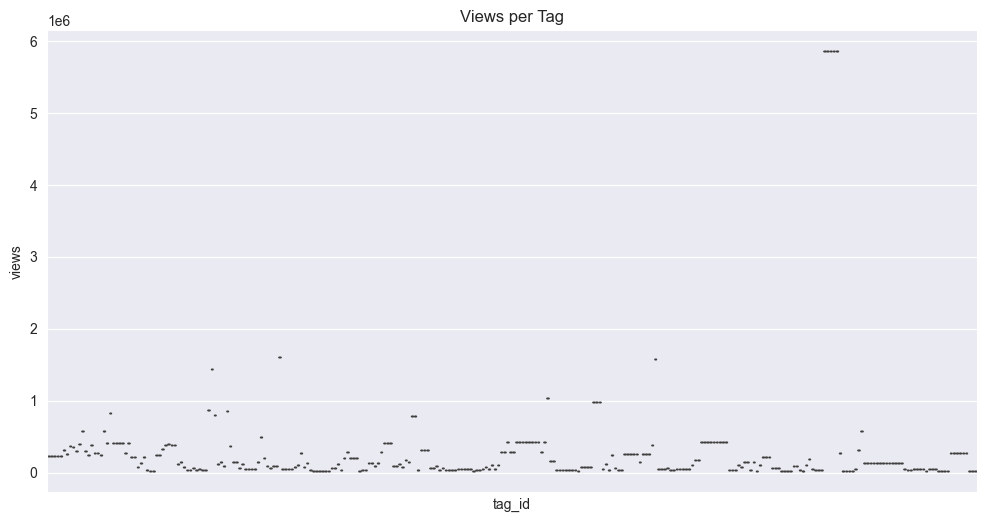

In [139]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='tag_id', y='views', data=df)
plt.xticks([])
plt.title('Views per Tag')
plt.show()

### een scatterplot maken om verband tussen views en likes per tag te zien

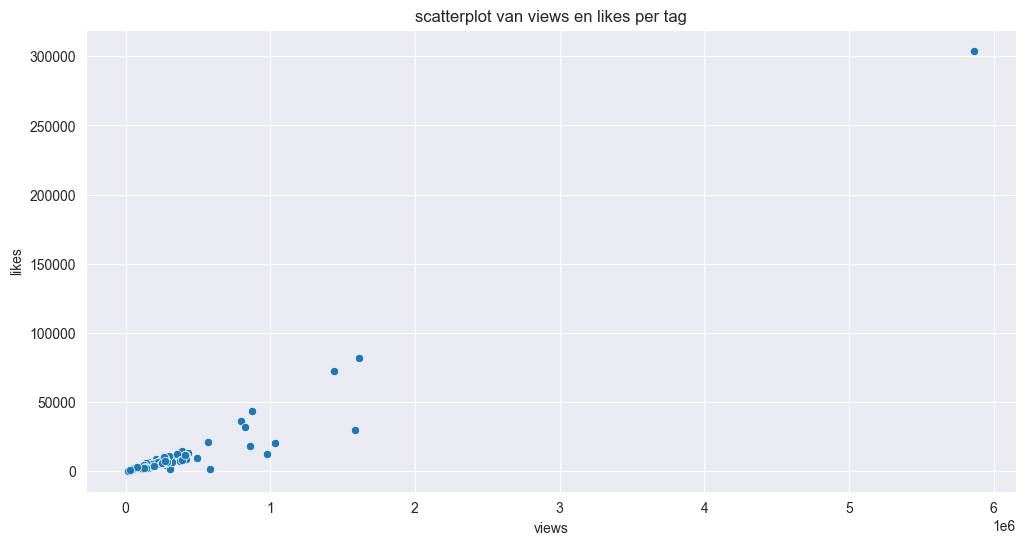

In [140]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='views', y='likes', data=df)
plt.title('scatterplot van views en likes per tag')
plt.show()

### In deze scatterplot is te zien dat de meeste tags erg clusteren. Echter zijn er een aantal uitschieters die veel populairder zijn dan de rest. Ik denk wel dat er een verband is tussen de video tags en de populariteit van de video.

# Kijken of er een verband is tussen category en gemiddelde weergaven per video.
#### eerst de data inladen

In [141]:
query = """
SELECT vd.category_id, AVG(s.views) AS average_views
FROM video_data vd
JOIN statistic s ON vd.video_id = s.video_id
GROUP BY vd.category_id
ORDER BY average_views DESC;
"""
cur.execute(query)
results = cur.fetchall()
df = pd.DataFrame(results, columns=['category', 'average_views'])
print(df)

   category        average_views
0        25  930197.372093023256
1        22  292483.329113924051
2        28  149430.869674185464
3        29  129543.880000000000
4        27   49972.500000000000
5        24   44011.000000000000
6        15   23944.000000000000


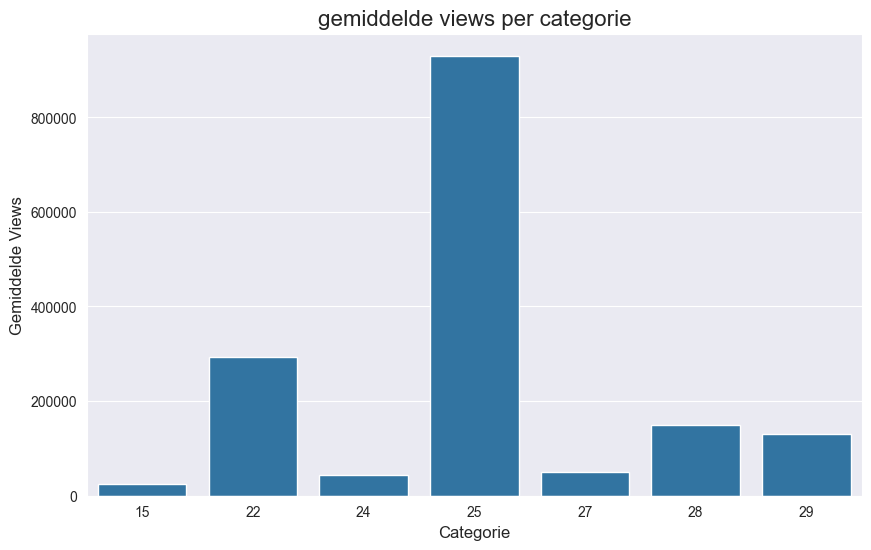

In [142]:
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='average_views', data=df)

plt.title('gemiddelde views per categorie', fontsize=16)
plt.xlabel('Categorie', fontsize=12)
plt.ylabel('Gemiddelde Views', fontsize=12)
plt.show()

### In deze staafdiagram is te zien dat somige categorieen veel populairder zijn dan anderen. Daarom geloof ik dat er dus een sterk verband is tussen de categorie en de populariteit. Daarom ga ik zeker de gemiddelde views van de categorie meenemen bij het bepalen van de populariteit van een video

#  Kijken of er verband is tussen like-percentage en populariteit

In [143]:
query = """
SELECT t.name AS tag_name, 
       SUM(s.views) AS total_views,
       SUM(s.likes) AS total_likes
FROM tags t
JOIN video_tags vt ON t.id = vt.tag_id
JOIN video_data vd ON vt.video_id = vd.video_id
JOIN statistic s ON s.video_id = vd.video_id
GROUP BY t.name;
"""
cur.execute(query)
results = cur.fetchall()

df = pd.DataFrame(results, columns=['tag_name', 'total_views', 'total_likes'])
df['like_percentage'] = (df['total_likes'] / df['total_views']) * 100



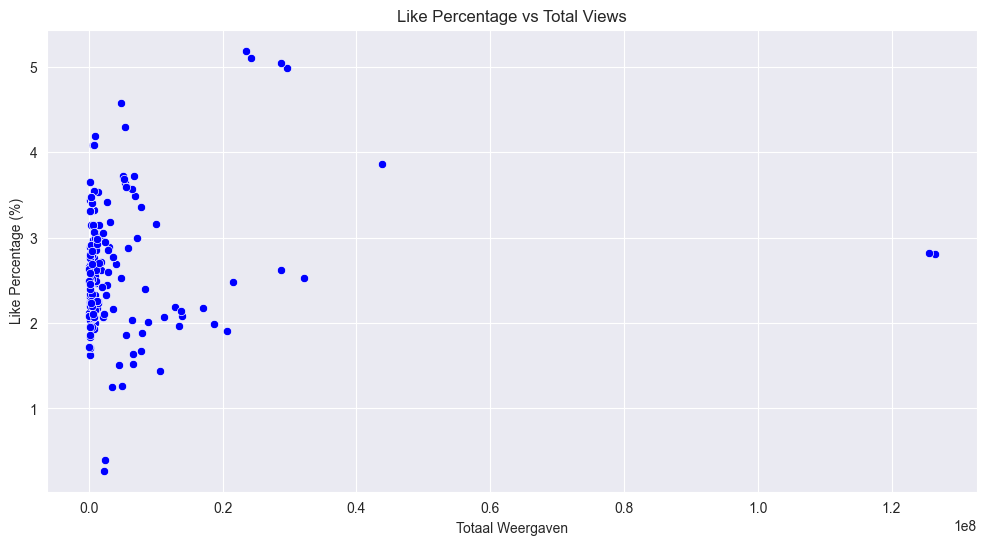

In [144]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='total_views', y='like_percentage', data=df, color='blue')
plt.title('Like Percentage vs Total Views')
plt.xlabel('Totaal Weergaven')
plt.ylabel('Like Percentage (%)')
plt.grid(True)
plt.show()

correlation = df['total_views'].corr(df['like_percentage'])

## helaas is er geen duidelijke trendlijn te zien. Daarom lijkt het mij nier verstandig om het like percentage te gebruiken voor het model.

# groei in weergaven berekenen (controleren wanneer er meer info over is)

In [145]:
query = """
SELECT vd.video_id, vd.title, d.date, sf.views
FROM video_data vd
JOIN statistic sf ON vd.video_id = sf.video_id
JOIN date d ON sf.date = d.id
ORDER BY vd.video_id, d.date;
"""
cur.execute(query)
rows = cur.fetchall()
df = pd.DataFrame(rows, columns=['video_id', 'title', 'date', 'views'])
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['video_id', 'date'])
df['growth'] = df.groupby('video_id')['views'].diff().fillna(0)
plt.figure(figsize=(12, 8))
videos = df['title'].unique()

<Figure size 1200x800 with 0 Axes>

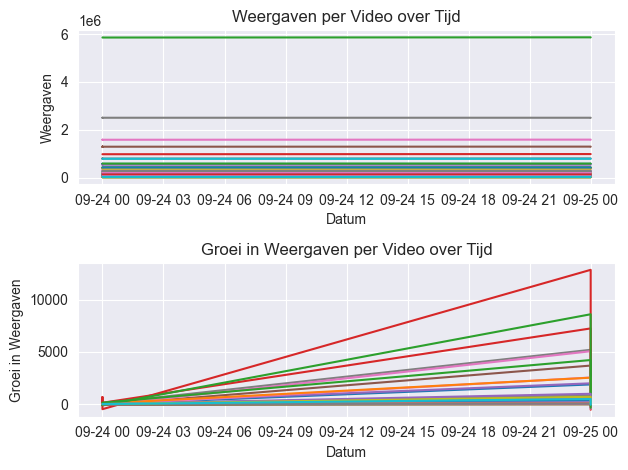

In [146]:
for video in videos:
    video_data = df[df['title'] == video]
    
    # Eerste subplot voor weergaven
    plt.subplot(2, 1, 1)
    plt.plot(video_data['date'], video_data['views'], label=video)
    plt.title('Weergaven per Video over Tijd')
    plt.xlabel('Datum')
    plt.ylabel('Weergaven')

    # Tweede subplot voor groei
    plt.subplot(2, 1, 2)
    plt.plot(video_data['date'], video_data['growth'], label=video)
    plt.title('Groei in Weergaven per Video over Tijd')
    plt.xlabel('Datum')
    plt.ylabel('Groei in Weergaven')

# Layout aanpassen en plot tonen
plt.tight_layout()
plt.show()

## in deze plot is het totaal aantal weergaven over tijd te zien en de groei van deze weergaven. Dit is interessant omdat je ziet dat de oudere video's minder snel groeien dan de net geuploade videos.
